
# Step 03 — Normalisation, HVG selection and scaling

**Purpose.** Put the cells on a comparable scale, pick the genes that carry
between-cell signal, and produce the matrix that PCA will consume — while keeping
the raw counts and the log-normalised values intact for everything else.

## The four representations, and why mixing them up matters

| Where | What it holds | Correct use |
|---|---|---|
| `adata.layers["counts"]` | raw integer UMIs | EGFP positivity call; any count-based model |
| `adata.layers["lognorm"]` | normalised + `log1p` | **all differential expression, dotplots, violins, any quoted expression value** |
| `adata.raw` | frozen lognorm over *all* genes | plotting genes that were not selected as HVGs |
| `adata.X` after scaling | z-scores over HVGs, clipped at ±10 | PCA / neighbours / UMAP **only** |

Running `rank_genes_groups` on the scaled matrix is the classic error: it tests
z-scores rather than expression, and restricts the result to 2,000 genes.

## What the paper did instead

Bise et al. used **SCTransform** — a regularised negative-binomial model whose
Pearson residuals replace log-normalisation — with mitochondrial and ribosomal
percentage regressed out during normalisation, followed by Seurat's anchor-based
integration.

This pipeline uses `normalize_total` + `log1p`, which is what the project guide
specifies. **That is a different estimator, not a re-implementation.** SCTransform
downweights highly expressed genes differently and typically yields somewhat
different HVGs and cluster boundaries. See `docs/method_comparison.md`. The
closest Scanpy analogue is
`sc.experimental.pp.normalize_pearson_residuals`; it is not used here because the
guide's baseline takes precedence and switching would be an undocumented change.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
adata = io_utils.load_checkpoint("qc_filtered")

Loaded 'qc_filtered': 15893 cells x 22813 genes



## 1. Preserve counts, then normalise and log-transform

In [3]:
adata = preprocessing.normalize_and_log(adata)
print(f"Layers now present: {preprocessing.layer_names(adata)}")
print(f".raw holds {adata.raw.n_vars} genes (all genes, log-normalised)")

Normalised to 10000 counts/cell and log1p-transformed; stored in layers['lognorm'] and .raw
Layers now present: ['counts', 'lognorm']
.raw holds 22813 genes (all genes, log-normalised)



## 2. Highly variable genes

2,000 HVGs, selected **per sample** and combined (`batch_key="sample"`). Without
the batch key, a gene that is variable only in one injured sample can be selected
on the strength of that one run.

Selected 2000 highly variable genes (requested 2000).
Saved figure_s1_hvg -> figures\figure_01_qc/ (png, pdf)


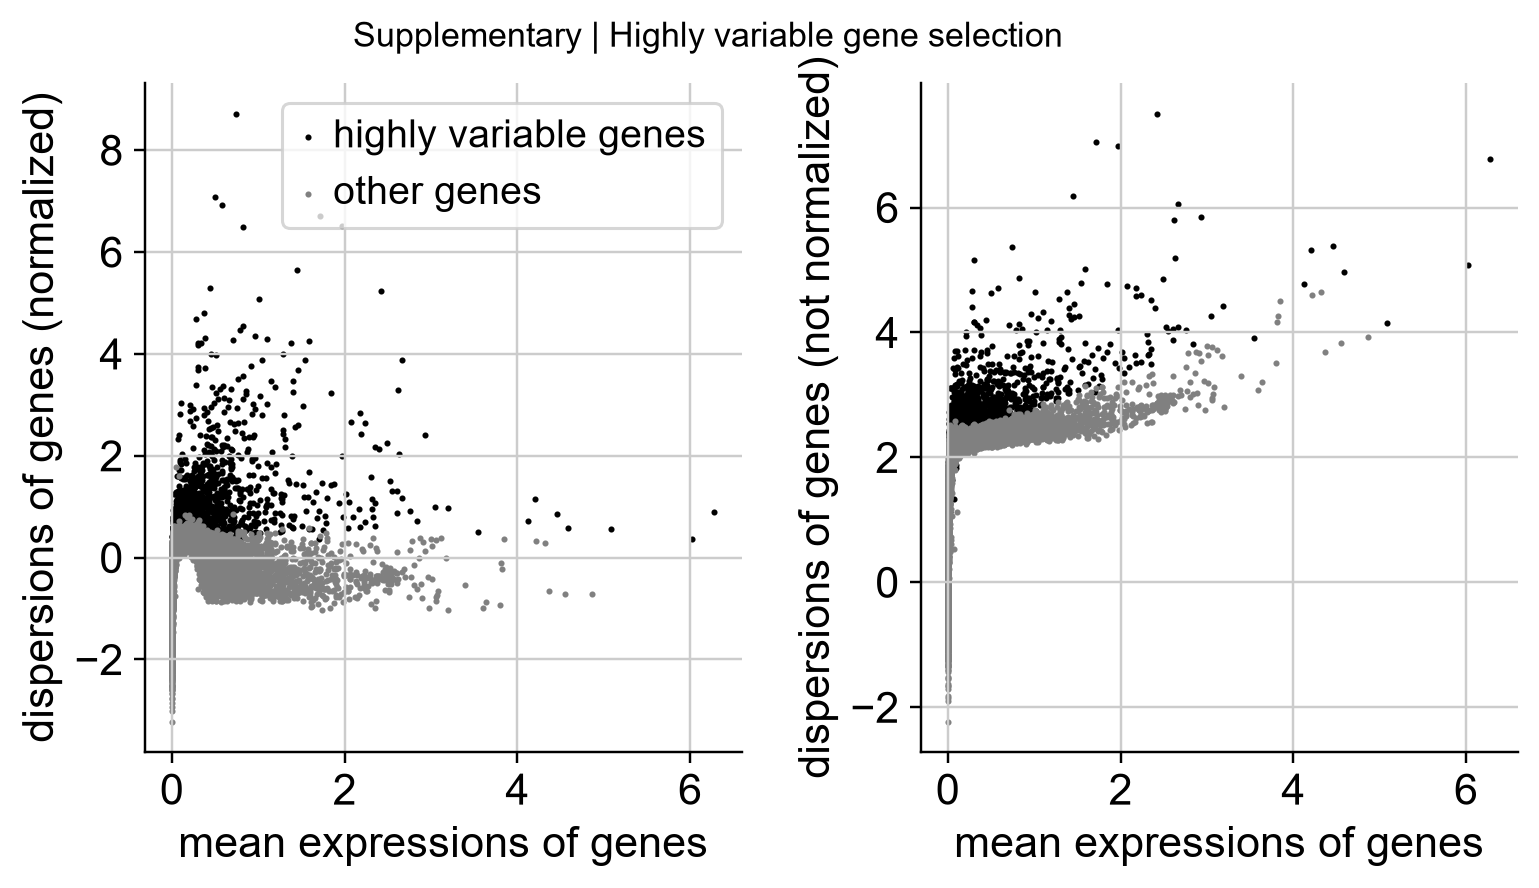

In [4]:
adata = preprocessing.select_hvgs(adata)
fig = plotting.figure_hvg(adata)

In [5]:
# Are the canonical markers we need for annotation inside the HVG set?
# They do not have to be: .raw keeps every gene available for plotting and DE.
hvg_genes = set(adata.var_names[adata.var["highly_variable"]])
for cell_type, genes in cfg.MARKERS_GUIDE.items():
    present = [g for g in genes if g in adata.var_names]
    in_hvg = [g for g in present if g in hvg_genes]
    print(f"{cell_type:<28} present: {len(present)}/{len(genes)}   in HVG set: {len(in_hvg)}")

Muller glia (resting)        present: 3/3   in HVG set: 2
Activated MG / progenitor    present: 4/4   in HVG set: 2
Rod photoreceptors           present: 3/3   in HVG set: 2
Cone photoreceptors          present: 4/4   in HVG set: 4
Bipolar cells                present: 2/3   in HVG set: 1
Amacrine cells               present: 3/3   in HVG set: 3
Retinal ganglion cells       present: 3/3   in HVG set: 2
Microglia / immune           present: 3/3   in HVG set: 3



## 3. Preserve the transgene before subsetting

`regress_and_scale` subsets to the 2,000 HVGs, which removes every other gene from
`.X` and the layers. EGFP is a single-copy transgene and is **not** guaranteed to
be selected as highly variable, so its raw counts are copied into `.obs` first.
This changes no analysis — it keeps a number reachable that Step 06 depends on.

(`.raw` also retains all genes, so the sub-analyses in Step 06 rebuild from there.)

In [6]:
egfp_name = io_utils.find_egfp_feature(adata, verbose=False)
if egfp_name is not None:
    preprocessing.preserve_gene_counts_in_obs(adata, egfp_name, obs_key="egfp_counts")
else:
    print("No EGFP feature to preserve.")

Preserved raw counts of 'EGFP' in obs['egfp_counts'] before HVG subsetting.



## 4. Regress technical covariates, then scale

**Documented deviation.** The guide's snippet calls `regress_out` on the full gene
set. We keep the same covariates (`total_counts`, `pct_counts_mt`) and keep the
step enabled, but run it *after* subsetting to HVGs. The genes dropped are exactly
the ones discarded before PCA anyway, so the result is unchanged while the runtime
falls from hours to minutes on ~50k cells. Set
`cfg.REGRESS_ON_HVG_SUBSET = False` to reproduce the guide's literal order.

Note that regressing `total_counts` after library-size normalisation is partly
redundant; it is retained because it is the prescribed baseline.

In [7]:
adata = preprocessing.regress_and_scale(adata)
print(f"adata.X is now scaled: shape {adata.shape}, "
      f"mean {adata.X.mean():.3f}, sd {adata.X.std():.3f}")

Subset to 2000 HVGs before regression/scaling.
Regressing out ['total_counts', 'pct_counts_mt'] (this is the slow step) ...


D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


Scaled to unit variance, clipped at +/-10.0. adata.X is now z-scores -- use layers['lognorm'] or .raw for expression.
adata.X is now scaled: shape (15893, 2000), mean -0.007, sd 0.888


In [8]:
summary = preprocessing.preprocessing_summary(adata)
io_utils.save_table(summary, "preprocessing_summary.csv")
display(summary.T)

Wrote tables\preprocessing_summary.csv  (1 rows)


,0
n_cells,15893
n_genes_in_X,2000
n_genes_in_raw,22813
target_sum,10000.0
n_top_hvg_requested,2000
hvg_batch_key,sample
regress_out,True
regress_covariates,"total_counts,pct_counts_mt"
regress_on_hvg_subset,True
scale_max_value,10.0


In [9]:
io_utils.save_checkpoint(adata, "preprocessed")

Saved checkpoint 'preprocessed' -> results\03_preprocessed.h5ad (172.3 MB)


WindowsPath('D:/retina/project1_zebrafish_retina/results/03_preprocessed.h5ad')


### What to check before continuing

- [ ] `layers['counts']` still holds integers (`adata.layers['counts'].max()` is a whole number).
- [ ] `adata.raw` exists and covers all genes, not just the HVGs.
- [ ] The scaled `adata.X` has mean ≈ 0 and sd ≈ 1.
- [ ] The HVG plot shows a normal-looking mean/dispersion cloud, not a degenerate line.
- [ ] You can state in one sentence which matrix you will use for DE (`lognorm` / `.raw`).